In [17]:
participants75 = [3,4,6,7,10,11,12, 14, 16,18,19, 23, 25, 26, 27, 32, 33, 34, 37, 38, 40, 41, 42, 44, 46, 47, 48, 51, 56, 59]
participants99 = [1,2,5,8,9,13,15, 17,20,21,22, 24, 28, 29, 30, 31, 35, 36, 39, 43, 45, 49, 50, 52, 53, 54, 55, 57, 58, 60]

avgReaction99 = []
avgReaction75 = []
avgDuration99 = []
avgDuration75 = []
missedEvents99 = []
missedEvents75 = []
missedDuration99 = []
missedDuration75 = []


import json
import glob
import os
import statistics

files = glob.glob(os.path.join("Data", "*.json" ))

import numpy as np


for file in files:
    with open(file) as f:
        dataParticipant = json.load(f)
    participantNum = int(''.join(filter(str.isdigit, os.path.basename(file))))
    danger = False
    reacted = False
    startDang = 0
    userReaction = []
    missedEvents = 0
    missedDuration = []
    totalTime = 0
    
    for item in dataParticipant:
        temp = item.get("temp")
        step = item.get("step")
        click = item.get("click")
        
        if (temp != None) and (temp > 315 or temp < 295):
            totalTime += 1
            if danger == False:
                startDang = step
                danger = True
                reacted = False
                
        if (click != None) and (danger == True) and (reacted == False):
            reactionTime = step - startDang
            userReaction.append(reactionTime)
            reacted = True
            danger = False
        if (danger and temp is not None) and (295 <= temp <= 315):
            duration = step - startDang
            missedDuration.append(duration)
            missedEvents += 1
            danger = False
            reacted = False

    if participantNum in participants99:
        missedEvents99.append(missedEvents)
    else:
        missedEvents75.append(missedEvents)    
    if userReaction:
        avgReaction = statistics.mean(userReaction)
        if participantNum in participants99:
            avgReaction99.append(round(avgReaction, 2))
        else:
            avgReaction75.append(round(avgReaction, 2))
    else: 
        avgReaction = None
        if participantNum in participants99:
            avgReaction99.append(0)
        else:
            avgReaction75.append(0)
    if missedDuration:
        avgDuration = statistics.mean(missedDuration)
        if participantNum in participants99:
            avgDuration99.append(round(avgDuration, 2))
        else:
            avgDuration75.append(round(avgDuration, 2))
    else: 
        avgReaction = None
        if participantNum in participants99:
            avgDuration99.append(0)
        else:
            avgDuration75.append(0)


import pandas as pd


avgReaction99np = np.array(avgReaction99)
avgReaction75np = np.array(avgReaction75)
missedEvents99np = np.array(missedEvents99)
missedEvents75np = np.array(missedEvents75)


print("99% mean reaction: ", np.mean(avgReaction99np))
print("99% SD reaction time: ", avgReaction99np.std(ddof = 1))
print("75% mean reaction: ", np.mean(avgReaction75np))
print("75% SD reaction time: ", avgReaction75np.std(ddof = 1))
print("99% missed events: ", np.mean(missedEvents99np))
print("99% SD missed events: ", missedEvents99np.std(ddof = 1))
print("75% missed events: ", np.mean(missedEvents75np))
print("75% SD missed events: ", missedEvents75np.std(ddof = 1))

99% mean reaction:  3.518666666666667
99% SD reaction time:  5.528211491870636
75% mean reaction:  2.3669999999999995
75% SD reaction time:  4.592605863852205
99% missed events:  2.533333333333333
99% SD missed events:  1.1957780134587124
75% missed events:  2.7
75% SD missed events:  1.2077336998093464


In [15]:
from scipy import stats

from scipy.stats import shapiro
print(shapiro(avgReaction99))
print(shapiro(avgReaction75))
from scipy.stats import levene
print(levene(avgReaction99, avgReaction75))
#both groups violate normality, standard t-test is not good to use

from scipy.stats import mannwhitneyu

uStat, pValue = mannwhitneyu(avgReaction99,avgReaction75,alternative='two-sided')

print("U =", uStat)
print("p =", pValue)

uStat, pValue = mannwhitneyu(missedEvents99,missedEvents75,alternative='two-sided')

print("U =", uStat)
print("p =", pValue)

uStat, pValue = mannwhitneyu(avgDuration99,avgDuration75,alternative='two-sided')

print("U =", uStat)
print("p =", pValue)

ShapiroResult(statistic=0.5383905428839952, pvalue=1.397742201322629e-08)
ShapiroResult(statistic=0.3806807897698816, pvalue=3.6031809924798045e-10)
LeveneResult(statistic=0.452802567511301, pvalue=0.5036794101705684)
U = 529.0
p = 0.2438455449045378
U = 406.5
p = 0.5115100410845252
U = 360.0
p = 0.1656258786339262


In [21]:
import pandas as pd

df = pd.read_excel("TrustData.xlsx")

Cronbach alpha: (0.8807107641741989, array([0.817, 0.925]))
ShapiroResult(statistic=0.9211299929283432, pvalue=0.02869660404274552)
ShapiroResult(statistic=0.9627304547385205, pvalue=0.36305858278394154)
LeveneResult(statistic=0.4244109468754569, pvalue=0.5173173379620326)
99% mean trust scores:  4.8
99% SD trust scores:  1.0080138659874618
75% mean trust scores:  3.644444444444444
75% SD trust scores:  1.183971281278158


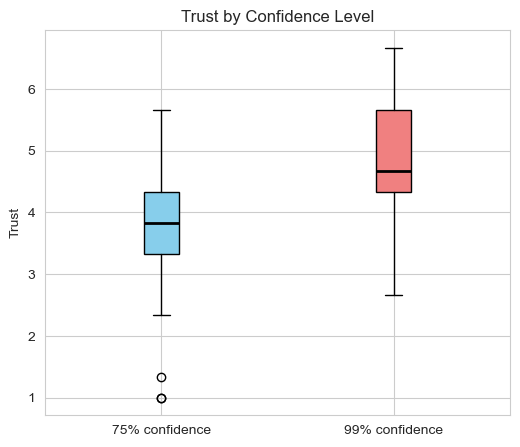

t = 4.070371889499199  p = 0.00014736151025063768
effect size 1.0509655027267477


In [22]:
import matplotlib.pyplot as plt
#!pip install cohens-d-effect-size
df = df.rename(columns={
    df.columns[0]: "participant",
    df.columns[1]: "group",
    df.columns[2]: "q1",
    df.columns[3]: "q2",
    df.columns[4]: "q3"
})


from cohens_d import cohens_d
import pingouin as pg


dfTrust = df[["q1", "q2", "q3"]]
alpha = pg.cronbach_alpha(data=dfTrust)
print("Cronbach alpha:", alpha)
#trust in automation scale demonstrated good internal consistency (α = .88)


df["trust score"] = df[["q1", "q2", "q3"]].mean(axis=1)
#!pip install pingouin


trust99 =df[df["group"] == 99]["trust score"]
trust75 =df[df["group"] == 75]["trust score"]

mean75 = trust75.mean()
std75 = trust75.std()
mean99 = trust99.mean()
std99 = trust99.std()
length99 = (len(trust99))
length75 = len(trust75)

from scipy.stats import shapiro
print(shapiro(trust75))
print(shapiro(trust99))
#group 75 breaks normality (p = 0.042) -> slight deviation from normality (not critical)

from scipy.stats import levene
print(levene(trust75, trust99))
#homogeneity of variance is not broken (p = 0.854)

print("99% mean trust scores: ", np.mean(trust99))
print("99% SD trust scores: ", trust99.std(ddof = 1))
print("75% mean trust scores: ", np.mean(trust75))
print("75% SD trust scores: ", trust75.std(ddof = 1))

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")

plt.figure(figsize=(6, 5))

box = plt.boxplot(
    [trust75, trust99],
    labels=["75% confidence", "99% confidence"],
    patch_artist=True
)

# Match the same color scheme/style
box['boxes'][0].set_facecolor('skyblue')
box['boxes'][1].set_facecolor('lightcoral')

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.ylabel("Trust")
plt.title("Trust by Confidence Level")

plt.show()

tTest, pValue = stats.ttest_ind(trust99, trust75, equal_var=False)
print('t =',tTest, ' p =', pValue)
#there is statistical significance, we can reject the null hypothesis (t=3.3155, p = 0.0018)

effect_size = cohens_d(trust99, trust75)
print("effect size",  effect_size)
#strong effect size (-.966)

In [24]:
dfSagat = pd.read_excel("SAGAT.xlsx")
for item in dfSagat:
    print(item)

cols = [
    "Freeze 1 Temp",
    "True Temp",
    "Flow 1",
    "True flow",
    "Freeze 2 Temp",
    "True temp",
    "Freeze 2 Pressure",
    "Pressure"
]

dfSagat[cols] = dfSagat[cols].apply(pd.to_numeric, errors="coerce")

Unnamed: 0
Percentage 
Freeze 1 Temp
True Temp
Flow 1
True flow
Freeze 2 Temp
True temp
Freeze 2 Pressure
Pressure
Action 1
CorrectAction 1
CoreTemp 1
CorrectCore 1
Action 2
CorrectAction2
CoreTemp 2
CorrectCore 2


In [27]:
dfSagat["Temp1 Error"] = abs(dfSagat["Freeze 1 Temp"] - dfSagat["True Temp"])
dfSagat["Flow Error"] = abs(dfSagat["Flow 1"] - dfSagat["True flow"])
dfSagat["Temp2 Error"] = abs(dfSagat["Freeze 2 Temp"] - dfSagat["True temp"])
dfSagat["Pressure Error"] = abs(dfSagat["Freeze 2 Pressure"] - dfSagat["Pressure"])

dfSagat["NumericalError"] = dfSagat[["Temp1 Error", "Flow Error", "Temp2 Error", "Pressure Error"]].mean(axis = 1)

99% mean numerical error scores:  7.683666666666667
99% SD numerical scores:  13.93554016270761
75% mean numerical error scores:  2.69625
75% SD numerical scores:  4.146279374434635
Shapiro 75:
ShapiroResult(statistic=0.5940331398623552, pvalue=6.176547246607784e-08)
Shapiro 99:
ShapiroResult(statistic=0.47478318633506666, pvalue=2.929895042349418e-09)
Levene:
LeveneResult(statistic=3.0072959548158695, pvalue=0.08820304827688184)


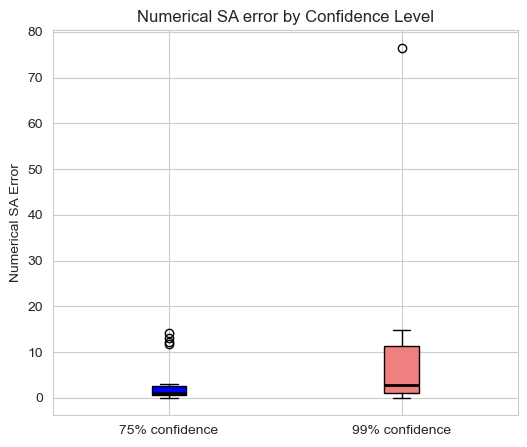

U = 615.0
p = 0.015007130506381614
0.4851181166569489


In [29]:


group99 = dfSagat[dfSagat["Percentage "] == 99]["NumericalError"]
group75 = dfSagat[dfSagat["Percentage "] == 75]["NumericalError"]
group99 = group99.dropna()
group75 = group75.dropna()

dfSagat["NumericalError"] = pd.to_numeric(
    dfSagat["NumericalError"],
    errors="coerce"
)

print("99% mean numerical error scores: ", np.mean(group99))
print("99% SD numerical scores: ", group99.std(ddof = 1))
print("75% mean numerical error scores: ", np.mean(group75))
print("75% SD numerical scores: ", group75.std(ddof = 1))

from scipy.stats import shapiro, levene

print("Shapiro 75:")
print(shapiro(group75))

print("Shapiro 99:")
print(shapiro(group99))

print("Levene:")
print(levene(group75, group99))

import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6,5))

box = plt.boxplot(
    [group75, group99],
    labels=["75% confidence", "99% confidence"],
    patch_artist=True
)

box['boxes'][0].set_facecolor('blue')
box['boxes'][1].set_facecolor('lightcoral')

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.ylabel("Numerical SA Error")
plt.title("Numerical SA error by Confidence Level")

plt.show()

from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(group99, group75, alternative='two-sided')

print("U =", u)
print("p =", p)

effectSize = cohens_d(group99, group75)
print(effectSize)

99% mean categorical scores:  1.3
99% SD categorical scores:  0.7943767889097848
75% mean categorical scores:  1.8
75% SD categorical scores:  0.9613209303008453
Checking if it meets the assumptions needed for a T-test
ShapiroResult(statistic=0.9077531391897136, pvalue=0.01306590708372585)
ShapiroResult(statistic=0.8593832820651847, pvalue=0.0009809747056698924)
LeveneResult(statistic=1.0401721664275463, pvalue=0.31201684795129603)


Mann–Whitney U = 581.5
p = 0.039796524462032336


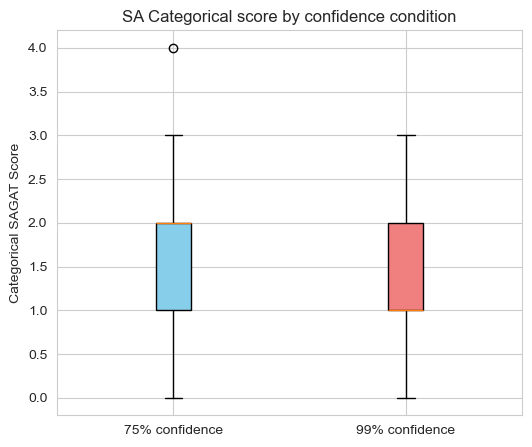

In [31]:

dfSagat["Action1Correct"] = (dfSagat["Action 1"] == dfSagat["CorrectAction 1"]).astype(int)
dfSagat["Action2Correct"] = (dfSagat["Action 2"] == dfSagat["CorrectAction2"]).astype(int)
dfSagat["CoreTemp1Correct"] = (dfSagat["CoreTemp 1"] == dfSagat["CorrectCore 1"]).astype(int)
dfSagat["CoreTemp2Correct"] = (dfSagat["CoreTemp 2"] == dfSagat["CorrectCore 2"]).astype(int)

dfSagat["CategoricalTotal"] = dfSagat["Action1Correct"]+ dfSagat["Action2Correct"] + dfSagat["CoreTemp1Correct"] + dfSagat["CoreTemp2Correct"]
dfSagat[["Action1Correct","Action2Correct","CoreTemp1Correct","CoreTemp2Correct","CategoricalTotal"]].head()


group75 = dfSagat[dfSagat["Percentage "]== 75]["CategoricalTotal"]
group99 = dfSagat[dfSagat["Percentage "] == 99]["CategoricalTotal"]

print("99% mean categorical scores: ", np.mean(group99))
print("99% SD categorical scores: ", group99.std(ddof = 1))
print("75% mean categorical scores: ", np.mean(group75))
print("75% SD categorical scores: ", group75.std(ddof = 1))

#tTest, pValue = stats.ttest_ind(group99, group75)
#print("t =", tTest)
#print("p value = ", pValue)

#effectSizeCat = cohens_d(group99, group75)
#print(effectSizeCat)

print("Checking if it meets the assumptions needed for a T-test")
from scipy.stats import shapiro
print(shapiro(group75))
print(shapiro(group99))
#both groups are break normality (p = 0.042 & p = 0.0008)

from scipy.stats import levene
print(levene(group75, group99))
#homogeneity of variance is not broken (p = 0.2249)

print("\n")

#can't do t-test because normality is broken
from scipy.stats import mannwhitneyu
uStat, pValue = mannwhitneyu(group75,group99,alternative='two-sided')

print("Mann–Whitney U =", uStat)
print("p =", pValue)
#there is a statistically significant difference between the groups of 99 and 75 percent
#U = 410.5
# p = 0.0025

data = [group75, group99]
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6,5))

box = plt.boxplot(
    data,
    labels=["75% confidence", "99% confidence"],
    patch_artist=True
)

box['boxes'][0].set_facecolor('skyblue')
box['boxes'][1].set_facecolor('lightcoral')

plt.ylabel("Categorical SAGAT Score")
plt.title("SA Categorical score by confidence condition")

plt.show()

60
60
60
60
      Trust  ReactionTime  SA_Numerical  SA_Categorical
0  5.666667          1.67        9.8625               1
1  6.333333          0.00        7.0375               1
2  3.333333          3.20        1.5050               3
3  3.666667          6.00        3.0075               2
4  4.666667          2.53        0.7700               2
rho = 0.3146651211674946
p = 0.014338692656898246
Trust vs Categorical SA
rho = -0.26234095926516937
p = 0.042871992127753916
Trust vs Reaction Time
rho = -0.37889969345152746
p = 0.002832245358990482


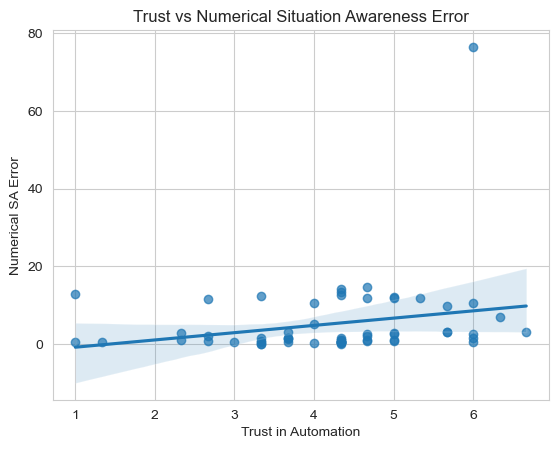

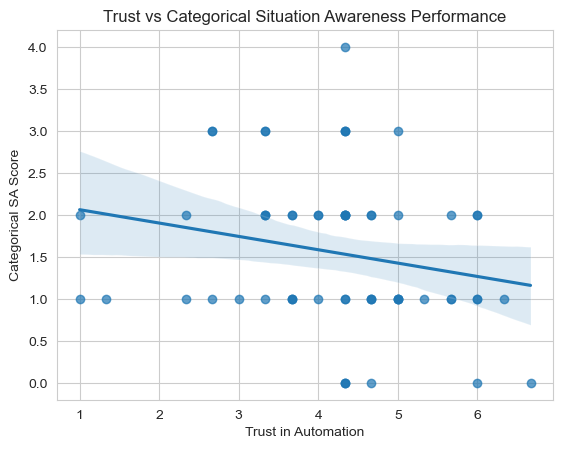

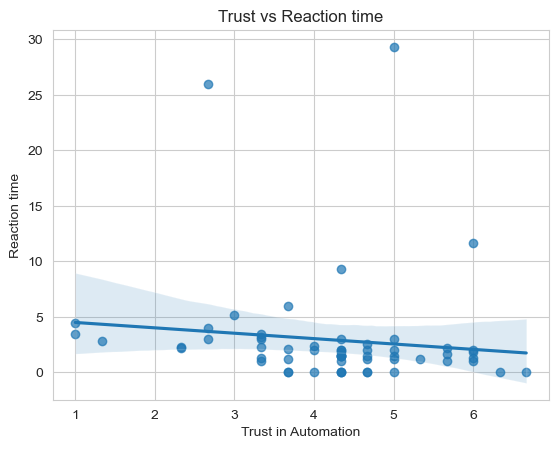

60 60
Trust vs Missed Events
rho = 0.2605818932599939
p = 0.044337522187141556


In [33]:
trustScores = df["trust score"].tolist()
reactionTime = avgReaction99 + avgReaction75
numericalError = dfSagat["NumericalError"].tolist()
catergoricalScore = dfSagat["CategoricalTotal"].tolist()

print(len(trustScores))
print(len(reactionTime))
print(len(numericalError))
print(len(catergoricalScore))

dfAnalysis = pd.DataFrame({
    "Trust": trustScores,
    "ReactionTime": reactionTime,
    "SA_Numerical": numericalError,
    "SA_Categorical": catergoricalScore
})

print(dfAnalysis.head())

dfAnalysis = dfAnalysis.dropna()

from scipy.stats import spearmanr

rho, p = spearmanr(
    dfAnalysis["Trust"],
    dfAnalysis["SA_Numerical"]
)
print("rho =", rho)
print("p =", p)
#rho = 0.311
#p = 0.0396
#Higher trust is connected with a greater numerical error

rho, p = spearmanr(
    dfAnalysis["Trust"],
    dfAnalysis["SA_Categorical"]
)

print("Trust vs Categorical SA")
print("rho =", rho)
print("p =", p)
#rho = -0.285
#p = 0.061

rho, p = spearmanr(
    dfAnalysis["Trust"],
    dfAnalysis["ReactionTime"]
)

print("Trust vs Reaction Time")
print("rho =", rho)
print("p =", p)
#rho = -.15
#p = .348
#not signficant 

import seaborn as sns

plt.figure()

sns.regplot(
    data=dfAnalysis,
    x="Trust",
    y="SA_Numerical",
    scatter_kws={"alpha": 0.7}
)

plt.title("Trust vs Numerical Situation Awareness Error")
plt.xlabel("Trust in Automation")
plt.ylabel("Numerical SA Error")

plt.show()

sns.regplot(
    data=dfAnalysis,
    x="Trust",
    y="SA_Categorical",
    scatter_kws={"alpha": 0.7}
)

plt.title("Trust vs Categorical Situation Awareness Performance")
plt.xlabel("Trust in Automation")
plt.ylabel("Categorical SA Score")

plt.show()

sns.regplot(
    data=dfAnalysis,
    x="Trust",
    y="ReactionTime",
    scatter_kws={"alpha": 0.7}
)

plt.title("Trust vs Reaction time")
plt.xlabel("Trust in Automation")
plt.ylabel("Reaction time")

plt.show()

missed_all = missedEvents75 + missedEvents99

# Safety check
print(len(missed_all), len(df["trust score"]))

# Build dataframe
df_corr = pd.DataFrame({
    "Trust": df["trust score"],
    "MissedEvents": missed_all
}).dropna()

# Spearman correlation (best for count data)
rho, p = spearmanr(df_corr["Trust"], df_corr["MissedEvents"])

print("Trust vs Missed Events")
print("rho =", rho)
print("p =", p)
